 # Trajectory analysis
 
This notebook is created to analyse the trajectory case series of the `SCENES` project.

In [6]:
import os
import re
import datetime
import math
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib.cm import get_cmap
from matplotlib import rcParams
from cmcrameri import cm     #Scientific color maps
from itertools import cycle
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import csv 
import random
from IPython.display import display, Markdown

In [7]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [8]:
# Set default font properties
rcParams['font.family'] = 'Arial'
# Disable LaTeX rendering for text
rcParams['text.usetex'] = False  # This prevents LaTeX formatting in the tick labels
rcParams['font.size'] = 12

In [12]:
# Root path- project directory
root_dir = os.path.abspath("..")

In [13]:
# Color palettes

# Choose the sequential color palette from cmcrameri
cmap = cm.batlow
cmap_seq = cm.oslo.reversed()
cmap_blues = plt.colormaps["Blues"] 

# Define the custom color palette
photoreceptor_colors = {
    'L cones': (0.8941, 0.1020, 0.1098),
    'M cones': (0.3020, 0.6863, 0.2902),
    'S cones': (0.2157, 0.4941, 0.7216),
    'Rods': (0.0157, 0.4118, 0.3333),
    'Melanopsin': (0.1255, 0.6549, 0.7686)   
}

In [20]:
# Create and save data tree for measurement folder

output_file = os.path.join("../results/datatree.txt")

lines = []

for dirpath, dirnames, filenames in os.walk(root_dir):
    # Skip hidden folders and files (like .git, .ipynb_checkpoints, etc.)
    dirnames[:] = [d for d in sorted(dirnames) if not d.startswith('.')]
    filenames = [f for f in sorted(filenames) if not f.startswith('.')]

    rel_path = os.path.relpath(dirpath, root_dir)
    depth = 0 if rel_path == "." else rel_path.count(os.sep) + 1
    indent = "│   " * (depth - 1)

    # Folder name
    folder_name = os.path.basename(dirpath) if rel_path != "." else os.path.basename(os.path.normpath(root_dir))
    lines.append(f"{indent}{folder_name}/")

    # Files inside folder
    for i, file in enumerate(filenames):
        connector = "└── " if i == len(filenames) - 1 else "├── "
        lines.append(f"{indent}    {connector}{file}")

tree_text = "\n".join(lines)

# Save to file
with open(output_file, "w", encoding="utf-8") as f:
    f.write(tree_text)
    


## Import Jeti-metadata file


In [23]:
# Data frame for merged metadata and jeti/klein df
merged_metadata_jeti_df = pd.read_csv(r'..\data\jeti_metadata_summary_tidy_scenes.csv', index_col=0, dtype={'time': str})

# Replace all NaN cells with blanks
merged_metadata_jeti_df = merged_metadata_jeti_df.fillna('')


In [24]:
merged_metadata_jeti_df.head()


,timestamp,project_id,project_name,project_start,data_curator,project_record,setup,device_geometry,measurement_id,record_id,date_x,time_x,protocol,available_$device,available_gloptic_spectis1,available_gigahertz-optic_msc15,available_jeti_spectraval1511,available_westborophotonics_wp690e-circ,wp690csv,available_kleininstruments_k-10a,available_inteldrealsense_d455,available_gopro_hero10black_video,available_gopro_hero10black_photo,location,latitude,longitude,direction,elevation,groundheight,boxtilt,boxheight,temperature,humidity,weather,other_weather,wind,scene,other_scene,view,other_view,lighting,other_lighting,technotes,available_all,date_y,time_y,Illuminance [lx] (CIE1931 2°),Irradiance [W/sqm] (380-780nm),Correlated Color Temp. (CCT) [K],Duv,dE2000 (CIE1931 2°),Dominant Wavelength (DWl) [nm] (CIE1931 2°),Color Purity (PE) [%] (CIE1931 2°),x,y,X,Y,Z,dE00,CCT [K],R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14,Ra,Re,DC,VS1,VS2,VS3,VS4,VS5,VS6,VS7,VS8,VS9,VS10,VS11,VS12,VS13,VS14,VS15,Qa,Qf,Qp,Qg,Rf,Rg,Rf (general color fidelity index),Rf1,Rf2,Rf3,Rf4,Rf5,Rf6,Rf7,Rf8,Rf9,Rf10,Rf11,Rf12,Rf13,Rf14,Rf15,Rf16,Rf17,Rf18,Rf19,Rf20,Rf21,Rf22,Rf23,Rf24,Rf25,Rf26,Rf27,Rf28,Rf29,Rf30,Rf31,Rf32,Rf33,Rf34,Rf35,Rf36,Rf37,Rf38,Rf39,Rf40,Rf41,Rf42,Rf43,Rf44,Rf45,Rf46,Rf47,Rf48,Rf49,Rf50,Rf51,Rf52,Rf53,Rf54,Rf55,Rf56,Rf57,Rf58,Rf59,Rf60,Rf61,Rf62,Rf63,Rf64,Rf65,Rf66,Rf67,Rf68,Rf69,Rf70,Rf71,Rf72,Rf73,Rf74,Rf75,Rf76,Rf77,Rf78,Rf79,Rf80,Rf81,Rf82,Rf83,Rf84,Rf85,Rf86,Rf87,Rf88,Rf89,Rf90,Rf91,Rf92,Rf93,Rf94,Rf95,Rf96,Rf97,Rf98,Rf99,Begin Wavelength [nm],End Wavelength [nm],Ephot (Begin..End) [uMol/s sqm],"X e,mel [W/sqm]","X v,mel,D65 (MEDI) [lx]","a mel,v (MEER)","m v,mel,D65 (MDER)",EML [lx],CCT [K].1,Esc [W/sqm],Emc [W/sqm],Elc [W/sqm],Erh [W/sqm],Emel [W/sqm],Peak Wavelength [nm],PEAK FWHM [nm],Centroid Wavelength [nm],R,G,B,Ratio Value,Mv [380; 780],dE1,dE2,dE3,dE4,dE5,Result of relevant equation,Effective Irradiance [mW/sqm],Damage Potential [W/sqm*lx],Maximum exposure time [h],Eb [W/m²],"Kb,v [W/lm]",Kc,R bp/fs [%],R lb/tb [%],R nbp/bp [%]
1,20230208T0800,101,SCENES,20230208,Niloufar Tabandeh,1,Full setup,,1001,1001_20230208T0800,20230208,800,Timelapse,,0,0,1,1,1,1,1,1,1,Tübingen-DE,48.537,9.059,120SE,460,4,0,130,-3.5,55.1,Clear,,No wind,Outdoor (countryside),,Outdoor,,Outdoor (daylight),,,2,20230208,800,12728.4,86.5,2899.0,0.000,25.4,583.2,55.6,0.445,0.407,13902.0,12728.0,4637.0,131.8,2899.4,91.9,96.4,96.9,91.4,92.5,96.2,93.9,86.2,71.7,93.1,90.4,94.3,92.4,98.1,93.2,91.8,0.0,97.8,93.3,93.4,95.5,96.5,95.1,96.9,98.4,96.1,94.7,94.9,97.5,93.6,97.0,97.8,95.6,94.3,98.2,102.5,95.0,101.5,95.0,96.0,93.1,93.8,94.2,89.2,92.5,91.8,90.0,98.9,91.8,89.2,90.6,94.7,97.7,95.0,91.0,90.8,94.6,91.9,90.5,91.7,90.9,96.9,94.7,92.9,93.5,96.6,98.1,93.7,94.4,94.5,93.5,95.4,96.9,98.7,96.7,98.7,95.2,99.2,98.5,97.6,97.9,95.9,99.8,96.3,95.7,96.6,92.4,96.2,97.0,97.3,96.6,95.5,96.5,96.7,95.1,94.9,95.4,96.6,98.8,96.9,97.6,97.3,94.6,94.3,94.9,94.7,95.2,97.0,94.7,96.1,98.1,94.2,97.6,96.8,94.7,95.6,95.9,96.4,96.8,89.4,98.7,97.4,97.9,94.1,89.6,95.0,94.3,92.7,94.2,97.2,91.5,94.0,89.4,93.7,94.9,93.7,94.0,92.1,400.0,700.0,271.5,8.8,6658.9,0.5,0.5,7348.2,2899.4,3.3,15.1,21.1,11.1,8.8,777.0,83340.0,746.1,19320.4,11408.5,4566.1,0.5,2.9,3.1,3.4,2.0,4.6,1.6,0.0,35.1,0.0,142.6,4.0,0.000,0.5,5.1,29.1,451.6
2,20230208T0830,101,SCENES,20230208,Niloufar Tabandeh,2,Full setup,,1001,1001_20230208T0830,20230208,830,Timelapse,,0,0,1,0,0,1,1,1,1,Tübingen-DE,48.537,9.059,120SE,460,4,0,130,-2.1,50.8,Clear,,No wind,Outdoor (countryside),,Outdoor,,Outdoor (daylight),,,1,20230208,830,44447.0,227.6,3910.0,0.005,19.8,577.0,34.7,0.389,0.393,43913.0,44447.0,24647.0,134.0,3910.2,98.8,98.3,98.1,96.3,98.7,98.4,96.0,96.0,93.4,97.2,97.2,93.5,98.0,99.1,97.6,97.1,0.0,99.2,94.6,93.1,90.3,92.4,92.6,94.6,95.4,98.2,98.2,96.1,94.9,94.0,97.0,98.5,94.7,94.8,94.6,97.4,94.9,97.7,94.9,98.2,96.7,95.0,96.0,94.8,97.6,97.8,97.1,98.4,95.9,94.8,95.5,97.0,98.4,94.3,94.0,93.6,94.4,93.9,89.1,93.2,90.9,95.7,94.4,93.6,91.7,92.1,97

## Trajectory data frame

In [29]:
trajectory_canada_df = merged_metadata_jeti_df[
    (merged_metadata_jeti_df['protocol'] == 'Trajectory') &
    (merged_metadata_jeti_df['location'] == 'Ottawa-CA')
]
trajectory_canada_df.head()

,timestamp,project_id,project_name,project_start,data_curator,project_record,setup,device_geometry,measurement_id,record_id,date_x,time_x,protocol,available_$device,available_gloptic_spectis1,available_gigahertz-optic_msc15,available_jeti_spectraval1511,available_westborophotonics_wp690e-circ,wp690csv,available_kleininstruments_k-10a,available_inteldrealsense_d455,available_gopro_hero10black_video,available_gopro_hero10black_photo,location,latitude,longitude,direction,elevation,groundheight,boxtilt,boxheight,temperature,humidity,weather,other_weather,wind,scene,other_scene,view,other_view,lighting,other_lighting,technotes,available_all,date_y,time_y,Illuminance [lx] (CIE1931 2°),Irradiance [W/sqm] (380-780nm),Correlated Color Temp. (CCT) [K],Duv,dE2000 (CIE1931 2°),Dominant Wavelength (DWl) [nm] (CIE1931 2°),Color Purity (PE) [%] (CIE1931 2°),x,y,X,Y,Z,dE00,CCT [K],R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14,Ra,Re,DC,VS1,VS2,VS3,VS4,VS5,VS6,VS7,VS8,VS9,VS10,VS11,VS12,VS13,VS14,VS15,Qa,Qf,Qp,Qg,Rf,Rg,Rf (general color fidelity index),Rf1,Rf2,Rf3,Rf4,Rf5,Rf6,Rf7,Rf8,Rf9,Rf10,Rf11,Rf12,Rf13,Rf14,Rf15,Rf16,Rf17,Rf18,Rf19,Rf20,Rf21,Rf22,Rf23,Rf24,Rf25,Rf26,Rf27,Rf28,Rf29,Rf30,Rf31,Rf32,Rf33,Rf34,Rf35,Rf36,Rf37,Rf38,Rf39,Rf40,Rf41,Rf42,Rf43,Rf44,Rf45,Rf46,Rf47,Rf48,Rf49,Rf50,Rf51,Rf52,Rf53,Rf54,Rf55,Rf56,Rf57,Rf58,Rf59,Rf60,Rf61,Rf62,Rf63,Rf64,Rf65,Rf66,Rf67,Rf68,Rf69,Rf70,Rf71,Rf72,Rf73,Rf74,Rf75,Rf76,Rf77,Rf78,Rf79,Rf80,Rf81,Rf82,Rf83,Rf84,Rf85,Rf86,Rf87,Rf88,Rf89,Rf90,Rf91,Rf92,Rf93,Rf94,Rf95,Rf96,Rf97,Rf98,Rf99,Begin Wavelength [nm],End Wavelength [nm],Ephot (Begin..End) [uMol/s sqm],"X e,mel [W/sqm]","X v,mel,D65 (MEDI) [lx]","a mel,v (MEER)","m v,mel,D65 (MDER)",EML [lx],CCT [K].1,Esc [W/sqm],Emc [W/sqm],Elc [W/sqm],Erh [W/sqm],Emel [W/sqm],Peak Wavelength [nm],PEAK FWHM [nm],Centroid Wavelength [nm],R,G,B,Ratio Value,Mv [380; 780],dE1,dE2,dE3,dE4,dE5,Result of relevant equation,Effective Irradiance [mW/sqm],Damage Potential [W/sqm*lx],Maximum exposure time [h],Eb [W/m²],"Kb,v [W/lm]",Kc,R bp/fs [%],R lb/tb [%],R nbp/bp [%]
227,20230614T0800,101,SCENES,20230208,Niloufar Tabandeh,227,Full setup,,1012,1012_20230614T0800,20230614,800,Trajectory,,0,0,1,1,1,1,1,1,1,Ottawa-CA,45.449,-75.630,243SW,100,0,0,116,20.1,63.2,Partially cloudy,,No wind,Indoor (bedroom),,Indoor w/ window,,Indoor (daylight),,wildfire smoke,2,20230614,800,36.1,0.1,3087.0,-0.002,23.4,583.3,47.0,0.428,0.395,39.0,36.1,16.1,57.2,3086.7,93.9,97.6,98.2,92.9,93.8,96.4,91.1,81.4,59.0,93.2,93.5,86.1,95.2,99.3,93.2,90.8,0.0,88.0,92.8,93.3,95.1,99.1,93.4,92.9,94.1,92.7,89.8,89.7,97.0,90.9,94.2,91.1,92.4,92.0,93.7,99.1,92.4,99.2,92.4,96.2,91.9,89.8,93.2,83.0,90.1,88.2,84.4,99.0,90.7,88.9,89.6,92.9,97.9,96.1,87.6,89.5,95.0,92.5,82.4,90.8,91.1,97.4,93.4,90.4,92.8,95.9,96.2,95.3,95.7,95.6,90.3,98.5,94.0,96.7,89.2,96.0,92.9,99.2,97.5,97.9,95.3,93.2,99.5,96.6,95.7,95.6,93.3,95.3,98.2,98.0,97.3,96.2,95.0,93.8,94.6,93.8,94.0,96.7,94.8,94.1,90.6,93.1,90.9,89.7,89.2,88.5,90.4,92.3,89.0,86.2,95.2,86.3,92.8,87.8,90.5,90.3,89.3,93.8,93.3,84.0,97.0,96.3,96.0,85.0,83.4,92.8,95.5,86.7,96.4,83.9,81.7,88.6,80.4,87.0,92.7,95.9,93.9,90.6,400.0,700.0,0.6,0.0,19.0,0.5,0.5,21.0,3086.7,0.0,0.0,0.1,0.0,0.0,612.0,154.9,604.7,52.5,32.8,16.0,0.2,2.1,2.2,0.9,2.1,3.2,2.0,0.0,0.1,0.0,75790.8,0.0,0.000,0.5,7.7,34.4,202.6
228,20230614T0830,101,SCENES,20230208,Niloufar Tabandeh,228,Full setup,,1012,1012_20230614T0830,20230614,830,Trajectory,,0,0,1,1,1,1,1,1,1,Ottawa-CA,45.449,-75.622,325NW,100,1,0,116,19.8,52.3,Partially cloudy,,No wind,Indoor (kitchen),,Indoor w/ window,,Indoor (daylight),,wildfire smoke,2,20230614,830,130.2,1.0,4825.0,0.016,20.0,566.6,24.6,0.355,0.394,117.4,130.2,83.2,106.3,4825.2,78.3,84.7,92.0,79.5,77.7,78.6,95.9,78.7,34.5,64.6,72.0,61.4,78.7,95.4,83.2,76.6,0.0,81.8,87.8,89.2,91.3,96.6,89.4,80.0,78.9,82.0,83.3,88.0,98.4,91.0,88.9,85.3,86.3,87.0,83.9,89.2,88.9,93.1,88.9,90.6,82.9,89.9,87.1,78.8,89.2,79.4,79.3,96.5,83.7,85.0,82.2,85.6,94.5,90.1,84.2,88.6,89.6,86.8,84.0,82.7,83.9,94.1

In [38]:
# Extract date part (first 8 characters: yyyymmdd)

trajectory_canada_df = trajectory_canada_df.copy()
trajectory_canada_df['date'] = trajectory_canada_df['timestamp'].str[:8]
trajectory_canada_dates = trajectory_canada_df['date'].unique()
trajectory_canada_dates = trajectory_canada_dates.tolist()
trajectory_canada_dates

['20230614', '20230616', '20230619']

In [37]:

trajectory_canada_df['time'] = trajectory_canada_df['timestamp'].str[9:]
trajectory_canada_times = trajectory_canada_df['time'].unique()
trajectory_canada_times = trajectory_canada_times.tolist()
trajectory_canada_times

['0800',
 '0830',
 '0900',
 '0930',
 '0945',
 '1000',
 '1030',
 '1100',
 '1130',
 '1200',
 '1230',
 '1300',
 '1330',
 '1400',
 '1430',
 '1500',
 '1530',
 '1600',
 '1630',
 '1700',
 '1730',
 '1800',
 '1830']

In [ ]:
# Create summary table  
grouped_df = canada_trajectory_df.groupby(['date', 'view']).size().reset_index(name='count')

# Create a new column 'type' based on 'view'
grouped_df['index'] = grouped_df['view'].apply(lambda x: 'Outdoor' if x == 'Outdoor' else 'Indoor')

# Pivot the DataFrame to have 'Outdoor' and 'Indoor' as separate columns
pivot_df = grouped_df.pivot_table(index='date', columns='index', values='count', aggfunc='sum', fill_value=0).reset_index()
# Add a 'Total' column to sum up counts for each date
pivot_df['Total'] = pivot_df[['Indoor', 'Outdoor']].sum(axis=1)

pivot_df


## Illuminance Jeti

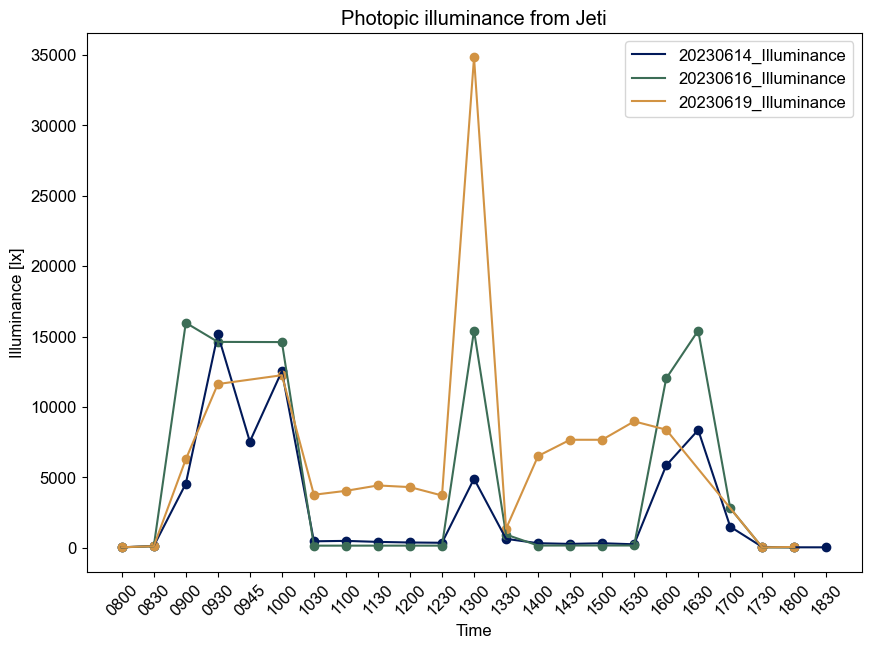

In [39]:
# Plot illuminace for each day in one plot (Jeti)

# Get a colormap and normalize it based on the number of groups
norm = plt.Normalize(0, len(trajectory_canada_df['date'].unique()))

plt.figure(figsize=(10, 7))

for i, (group, group_df) in enumerate(trajectory_canada_df.groupby('date')):

    jeti_values = pd.to_numeric(group_df['Illuminance [lx] (CIE1931 2°)'],
                                errors='coerce')

    color = cmap(norm(i))  # Get a color based on the index of the group
    plt.plot(group_df['time'],
             group_df['Illuminance [lx] (CIE1931 2°)'],
             label=f'{group}_Illuminance',
             color=color)
    plt.scatter(group_df['time'],
                group_df['Illuminance [lx] (CIE1931 2°)'],
                marker='o',
                color=color)

plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel('Illuminance [lx]')
plt.title(f'Photopic illuminance from Jeti')
plt.legend(loc='upper right')
#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Illuminance_Trajectory{group}.svg',dpi = 600, bbox_inches='tight')
#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Illuminance_Trajectory{group}.pdf',dpi = 600, bbox_inches='tight');

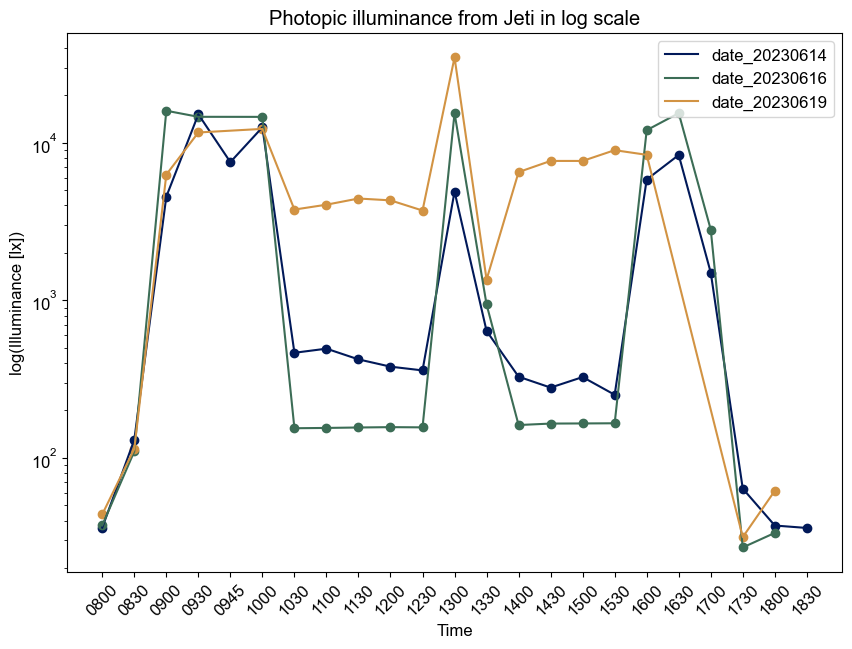

In [40]:
# Plot illuminace for each day in one plot, log10 scale (Jeti)

# Get a colormap and normalize it based on the number of groups

norm = plt.Normalize(0, len(trajectory_canada_df['date'].unique()))

plt.figure(figsize=(10, 7))

x_values = set()

for i, (group, group_df) in enumerate(trajectory_canada_df.groupby('date')):

    jeti_values = pd.to_numeric(group_df['Illuminance [lx] (CIE1931 2°)'],
                                errors='coerce')

    color = cmap(norm(i))  # Get a color based on the index of the group
    plt.plot(group_df['time'],
             group_df['Illuminance [lx] (CIE1931 2°)'],
             label=f'date_{group}',
             color=color)
    plt.scatter(group_df['time'],
                group_df['Illuminance [lx] (CIE1931 2°)'],
                marker='o',
                color=color)

    # Collect unique x values with corresponding y values
    valid_x_values = group_df.loc[~np.isnan(jeti_values), 'time'].unique()
    x_values.update(valid_x_values)

# Convert set to a sorted list
x_values = sorted(x_values)
plt.xticks(x_values, rotation=45)
plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('log(Illuminance [lx])')
plt.title('Photopic illuminance from Jeti in log scale')
plt.legend(loc='upper right')

#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Illuminance_Trajectory.pdf', dpi=600, bbox_inches='tight')

In [ ]:
correlation_coefficient = canada_trajectory_df['Illuminance [lx] (CIE1931 2°)'].corr(canada_trajectory_df['Klein_illuminance'])

print( f" Illuminance Correlation Coefficient between Jeti and Klein: {correlation_coefficient}")

## Illuminance and mEDI

In [43]:
# Pearson correlation coefficient

correlation_coefficient = trajectory_canada_df['Illuminance [lx] (CIE1931 2°)'].corr(trajectory_canada_df['X v,mel,D65 (MEDI) [lx]'])

print( f" Correlation Coefficient between mEDI and Illuminance from Jeti: {correlation_coefficient}")

 Correlation Coefficient between mEDI and Illuminance from Jeti: 0.9995190290327606


In [44]:
# Create a new column 'in/out' based on 'view'
trajectory_canada_df['in/out'] = trajectory_canada_df['view'].apply(lambda x: 'Outdoor' if x.startswith('Outdoor') else 'Indoor')


In [45]:
# Calculate correlation coefficient for Indoor data

# Calculate correlation coefficient for Indoor data
indoor_data = trajectory_canada_df[trajectory_canada_df['in/out'] == 'Indoor']
correlation_indoor = indoor_data['Illuminance [lx] (CIE1931 2°)'].corr(indoor_data['X v,mel,D65 (MEDI) [lx]'])

# Calculate correlation coefficient for Outdoor data
outdoor_data = trajectory_canada_df[trajectory_canada_df['in/out'] == 'Outdoor']
correlation_outdoor = outdoor_data['Illuminance [lx] (CIE1931 2°)'].corr(outdoor_data['X v,mel,D65 (MEDI) [lx]'])

# Print the results
print(f"Correlation Coefficient for Indoor data: {correlation_indoor}")
print(f"Correlation Coefficient for Outdoor data: {correlation_outdoor}")

Correlation Coefficient for Indoor data: 0.99966373253422
Correlation Coefficient for Outdoor data: 0.9990169563220191


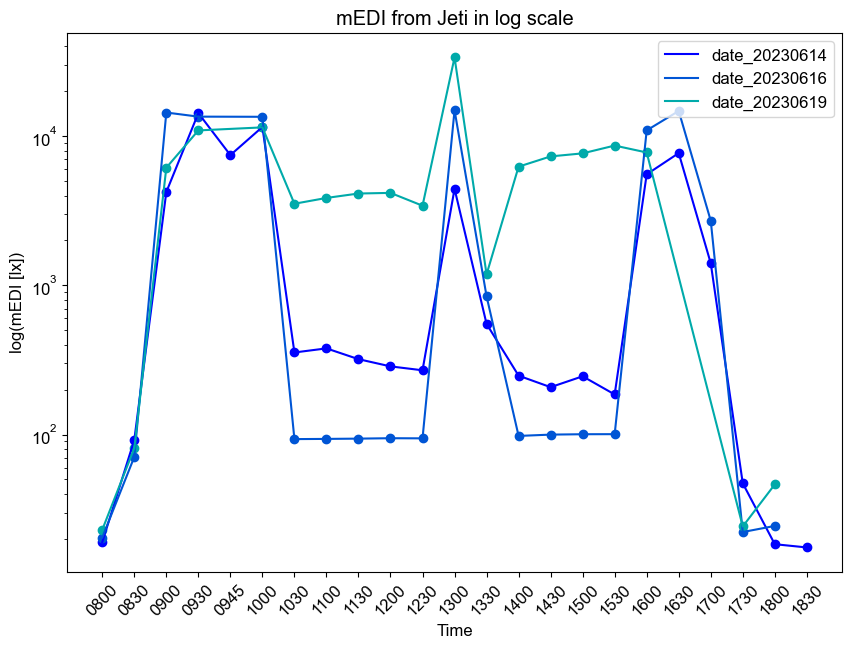

In [46]:
# Plot mEDI for each day in one plot, log10 scale (Jeti)

# Get a colormap and normalize it based on the number of groups
  
norm = plt.Normalize(0, len(trajectory_canada_df['date'].unique()))

plt.figure(figsize = (10,7)) 

x_values = set()

for i, (group, group_df) in enumerate(trajectory_canada_df.groupby('date')):
    
    jeti_values = pd.to_numeric(group_df['X v,mel,D65 (MEDI) [lx]'], errors='coerce')
    
    color = cmap(norm(i))  # Get a color based on the index of the group
    plt.plot(group_df['time'], jeti_values, label=f'date_{group}', color=color)
    plt.scatter(group_df['time'], jeti_values, marker='o', color=color)
    
    # Collect unique x values with corresponding y values
    valid_x_values = group_df.loc[~np.isnan(jeti_values), 'time'].unique()
    x_values.update(valid_x_values)
    
# Convert set to a sorted list
x_values = sorted(x_values)
plt.xticks(x_values, rotation=45)
plt.yscale('log')    
plt.xlabel('Time')
plt.ylabel('log(mEDI [lx])')
plt.title('mEDI from Jeti in log scale')
plt.legend(loc='upper right');

#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_mEDI_Trajectory.pdf',dpi = 600, bbox_inches='tight');

In [ ]:
# Plot illuminace and mEDI for each day in log scale (Jeti)

# Get a colormap and normalize it based on the number of groups
cmap_ill = mpl.colormaps['winter']  
cmap_medi = mpl.colormaps['autumn'] 
norm = plt.Normalize(0, len(trajectory_canada_df['date'].unique()))


for i, (group, group_df) in enumerate(trajectory_canada_df.groupby('date')):
    plt.figure(figsize = (8,5))  # Create a new figure for each group
    
    color_illuminance = cmap_ill(norm(i))

    color_medi = cmap_medi(norm(i))
        
    jeti_illuminance = pd.to_numeric(group_df['Illuminance [lx] (CIE1931 2°)'])
    
    plt.plot(group_df['time'], group_df['Illuminance [lx] (CIE1931 2°)'], label='Illuminance', color=color_illuminance)
    plt.scatter(group_df['time'], group_df['Illuminance [lx] (CIE1931 2°)'], marker='o', color=color_illuminance)
    
    jeti_medi = pd.to_numeric(group_df['X v,mel,D65 (MEDI) [lx]'], errors='coerce')
    
    plt.plot(group_df['time'], group_df['X v,mel,D65 (MEDI) [lx]'], label='mEDI', alpha = 0.8, color=color_medi)
    plt.scatter(group_df['time'], group_df['X v,mel,D65 (MEDI) [lx]'], marker='o', alpha = 0.8, color=color_medi)
    
    plt.yscale('log')
    plt.xlabel('Time')
    plt.xticks(rotation=45)
    plt.ylabel('log[lx]')
    plt.title(f'Photopic illuminance and mEDI from Jeti in log scale_date{group}')
    plt.legend(loc='upper right');

    # Adjust layout for better spacing
    plt.tight_layout()
    
    #plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Trajectory_{group}.pdf', dpi = 600, bbox_inches="tight");

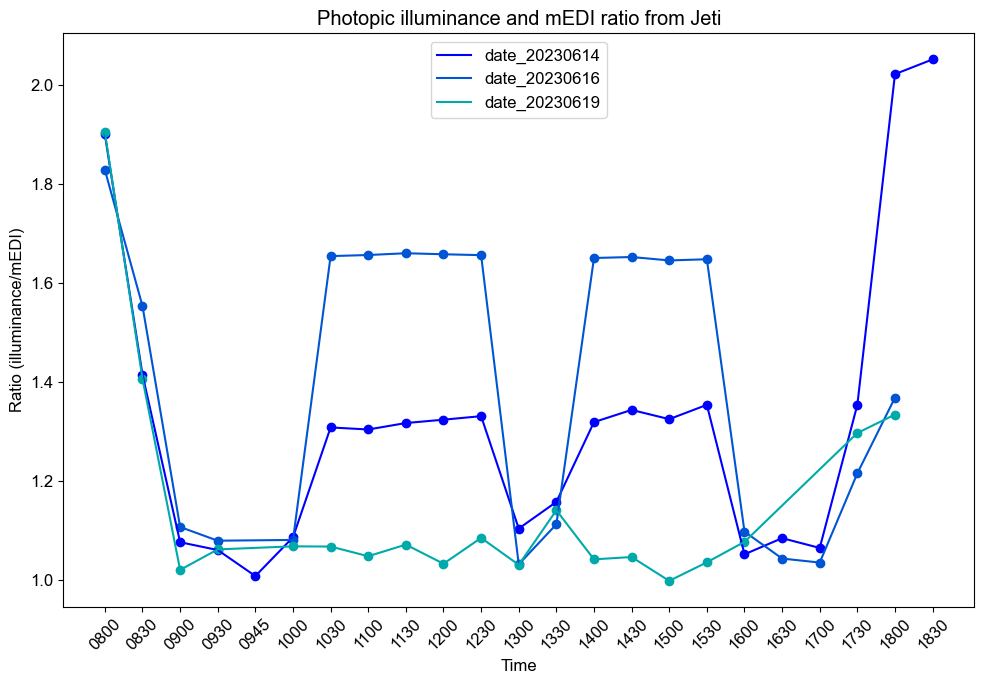

In [47]:
# Plot illuminace and mEDI ratio in one plot for all days in one plot (Jeti)

# Get a colormap and normalize it based on the number of groups 
 
norm = plt.Normalize(0, len(trajectory_canada_df['date'].unique()))
plt.figure(figsize = (10,7))
x_values = set()

for i, (group, group_df) in enumerate(trajectory_canada_df.groupby('date')):
    
    illuminance_values = pd.to_numeric(group_df['Illuminance [lx] (CIE1931 2°)'])
    medi_values = pd.to_numeric(group_df['X v,mel,D65 (MEDI) [lx]'], errors='coerce')
    ratio_values = illuminance_values / medi_values
    
    color = cmap(norm(i))
    
    plt.plot(group_df['time'], ratio_values, label=f'date_{group}', color=color)
    plt.scatter(group_df['time'], ratio_values, marker='o', color=color)
    # Collect unique x values with corresponding y values
    valid_x_values = group_df.loc[~np.isnan(ratio_values), 'time'].unique()
    x_values.update(valid_x_values)
    
# Convert set to a sorted list
x_values = sorted(x_values)
plt.xticks(x_values, rotation=45)
      
plt.xlabel('Time')
plt.ylabel('Ratio (illuminance/mEDI)')
plt.title('Photopic illuminance and mEDI ratio from Jeti')
plt.legend(loc='upper center');

# Adjust layout for better spacing
plt.tight_layout()

#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Trajectory_ratio.pdf', dpi = 600, bbox_inches="tight");

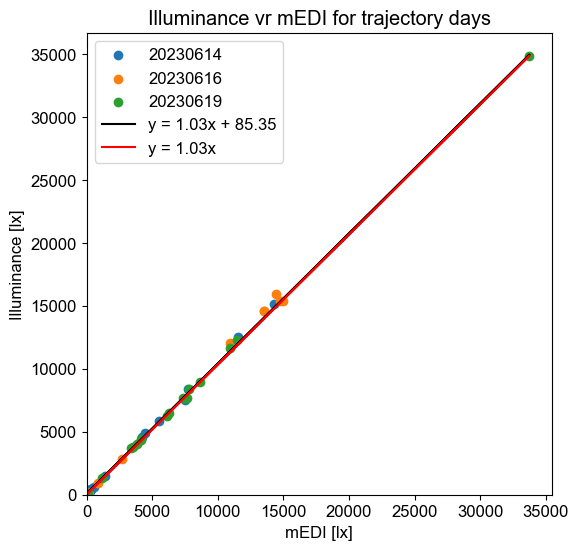

In [48]:
# Plot illumnance vr mEDI for all trajectory days in one plot (Jeti)

plt.figure(figsize=(6, 6)) 
for group, group_df in trajectory_canada_df.groupby('date'):
    # Drop rows with NaN values in the specified columns
    group_df = group_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])
    
    x_values = group_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
    y_values = group_df['Illuminance [lx] (CIE1931 2°)'].values
    
    scatter_plot = plt.scatter(x_values, y_values, label=group)
    

# Perform linear regression for y = mx + b
model = LinearRegression()
model.fit(x_values, y_values)
    
# Get regression line parameters
m = model.coef_[0]
b = model.intercept_

# Generate x values for the regression line
regression_line_x = np.linspace(0, x_values, 100).reshape(-1, 1)
    
# Calculate corresponding y values for the regression line
regression_line_y = m * regression_line_x + b
    
# Plot the regression line
plt.plot(regression_line_x, regression_line_y, color='black', label=f'y = {m:.2f}x + {b:.2f}')

# Perform linear regression for y = m2x
model_new = LinearRegression()
model_new.fit(x_values, y_values)

# Get regression line parameters for the new line
m2 = model_new.coef_[0]

# Calculate corresponding y values for the new regression line (y = mx)
regression_line_y_new = m2 * regression_line_x

# Plot the new regression line
plt.plot(regression_line_x, regression_line_y_new, color='red', label=f'y = {m:.2f}x')
    
# Set limits based on the current plot's maximum value
plt.xlim(0)
plt.ylim(0)
plt.xlabel('mEDI [lx]')
plt.ylabel('Illuminance [lx]')
plt.legend(loc = 'upper left')
plt.title(f'Illuminance vr mEDI for trajectory days');


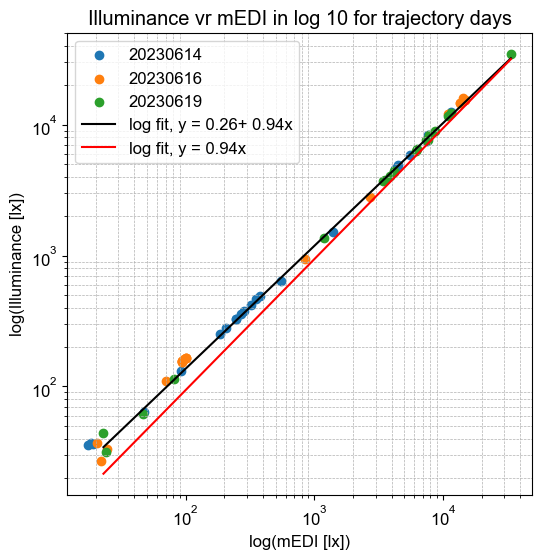

In [49]:

plt.figure(figsize=(6, 6)) 
for group, group_df in trajectory_canada_df.groupby('date'):
    group_df = group_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])
    
    x_values = group_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
    y_values = group_df['Illuminance [lx] (CIE1931 2°)'].values
    max_value = y_values.max()
    
    scatter_plot = plt.scatter(x_values, y_values, label=group)

# Perform linear regression for log-transformed values
model = LinearRegression()
model.fit(np.log10(x_values), np.log10(y_values))
    
    # Get regression line parameters
m = model.coef_[0]
b = model.intercept_

    # Generate log-transformed x values for the regression line
regression_line_x = np.linspace(x_values.min(), x_values.max(), 100)
regression_line_x_log = np.log10(regression_line_x)    
# Calculate corresponding log-transformed y values for the regression line
regression_line_y_log = m * regression_line_x_log + b
regression_line_y = 10 ** regression_line_y_log
# Plot the regression line
plt.plot(regression_line_x, regression_line_y, color='black', label=f'log fit, y = {b:.2f}+ {m:.2f}x')

# Perform linear regression for y = m2x
model_new = LinearRegression()
model_new.fit(np.log10(x_values), np.log10(y_values))

# Get regression line parameters for the new line
m2 = model_new.coef_[0]

# Calculate corresponding y values for the new regression line (y = mx)
regression_line_y_new = m2 * regression_line_x

# Plot the new regression line
plt.plot(regression_line_x, regression_line_y_new, color='red', label=f'log fit, y = {m2:.2f}x')



plt.xscale('log')  # Set x-axis to log scale
plt.yscale('log')  # Set y-axis to log scale

plt.xlabel('log(mEDI [lx])')
plt.ylabel('log(Illuminance [lx])')
plt.legend(loc='upper left')
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)
plt.title(f'Illuminance vr mEDI in log 10 for trajectory days');


#plt.savefig(f'results/trajectories/trajectory_plots/Jeti_Illuminance_vr_mEDI.pdf', dpi = 600, bbox_inches='tight');

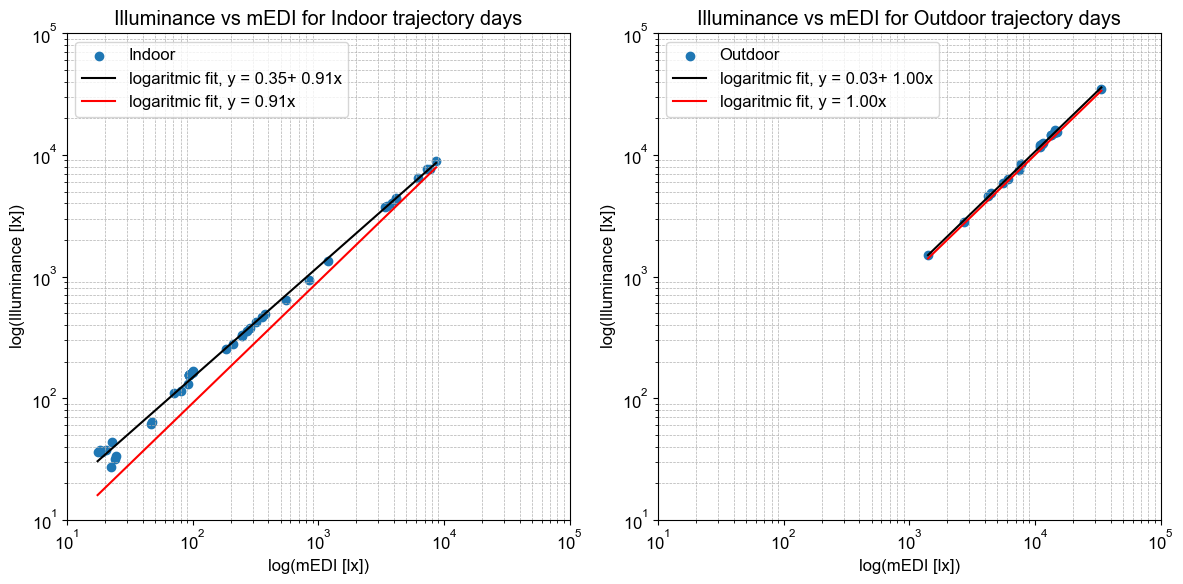

In [50]:
# Create subplots for two groups
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

for (group, group_df), ax in zip(trajectory_canada_df.groupby('in/out'), [ax1, ax2]):
    group_df = group_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])
    
    x_values = group_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
    y_values = group_df['Illuminance [lx] (CIE1931 2°)'].values
    max_value = y_values.max()
    
    scatter_plot = ax.scatter(x_values, y_values, label=group)

    # Perform linear regression for log-transformed values
    model = LinearRegression()
    model.fit(np.log10(x_values), np.log10(y_values))
    
    # Get regression line parameters
    m = model.coef_[0]
    b = model.intercept_

    # Generate log-transformed x values for the regression line
    regression_line_x = np.linspace(x_values.min(), x_values.max(), 100).reshape(-1, 1)
    regression_line_x_log = np.log10(regression_line_x)    
    # Calculate corresponding log-transformed y values for the regression line
    regression_line_y_log = m * regression_line_x_log + b
    regression_line_y = 10 ** regression_line_y_log
    # Plot the regression line
    ax.plot(regression_line_x, regression_line_y, color='black', label=f'logaritmic fit, y = {b:.2f}+ {m:.2f}x')

    # Perform linear regression for y = m2x
    model_new = LinearRegression()
    model_new.fit(np.log10(x_values), np.log10(y_values))

    # Get regression line parameters for the new line
    m2 = model_new.coef_[0]

    # Calculate corresponding y values for the new regression line (y = mx)
    regression_line_y_new = m2 * regression_line_x

    # Plot the new regression line
    ax.plot(regression_line_x, regression_line_y_new, color='red', label=f'logaritmic fit, y = {m2:.2f}x')

    ax.set_xscale('log')  # Set x-axis to log scale
    ax.set_yscale('log')  # Set y-axis to log scale

    ax.set_xlabel('log(mEDI [lx])')
    ax.set_ylabel('log(Illuminance [lx])')
    ax.legend(loc='upper left')
    ax.grid(True, which='minor', linestyle='--', linewidth=0.5)
    ax.set_title(f'Illuminance vs mEDI for {group} trajectory days')
    # Set x and y limits explicitly
    ax.set_xlim(10, 1e5)
    ax.set_ylim(10, 1e5)
plt.tight_layout()

#plt.savefig('results/trajectories/trajectory_plots/Jeti_Illuminance_vr_mEDI_inout.pdf', dpi = 600, bbox_inches='tight');

## Next step: Now I want table for fit and error. Not correct, will check it later

In [51]:
# Select the columns of interest
x_column = 'X v,mel,D65 (MEDI) [lx]'
y_column = 'Illuminance [lx] (CIE1931 2°)'

# Drop NaN values from the selected columns
cleaned_df = trajectory_canada_df[[x_column, y_column]].dropna()

In [52]:

# Perform linear regression for y = mx + b
tidy_trajectory_canada_df = trajectory_canada_df.dropna(subset=['X v,mel,D65 (MEDI) [lx]', 'Illuminance [lx] (CIE1931 2°)'])

x_values = tidy_trajectory_canada_df['X v,mel,D65 (MEDI) [lx]'].values.reshape(-1, 1)
y_values = tidy_trajectory_canada_df['Illuminance [lx] (CIE1931 2°)'].values

model = LinearRegression()
model.fit(x_values, y_values)
    
# Get regression line parameters
slope = model.coef_[0]
intercept = model.intercept_

# Calculate variance (mean squared error)
predictions = model.predict(x_values)
variance = mean_squared_error(y_values, predictions)

print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print (f'y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')
print(f"Variance (Mean Squared Error): {variance:.2f}")

Slope: 1.05
Intercept: 66.82
y = 1.05x + 66.82
Variance (Mean Squared Error): 39064.61


In [53]:
# Select the columns of interest
x_column = 'X v,mel,D65 (MEDI) [lx]'
y_column = 'Illuminance [lx] (CIE1931 2°)'

# Drop NaN values from the selected columns
tidy_trajectory_canada_df = tidy_trajectory_canada_df.dropna(subset=[x_column, y_column, 'in/out'])

# Group by 'in/out' and perform linear regression for each group
for group, group_df in tidy_trajectory_canada_df.groupby('in/out'):
    # Extract the x and y values for the current group
    x_values = group_df[x_column].values.reshape(-1, 1)
    y_values = group_df[y_column].values

    # Perform linear regression
    model = LinearRegression()
    model.fit(x_values, y_values)

    # Get regression line parameters
    slope = model.coef_[0]
    intercept = model.intercept_

    # Calculate variance (mean squared error)
    predictions = model.predict(x_values)
    variance = mean_squared_error(y_values, predictions)

    print(f"Group: {group}")
    print(f"Slope: {slope:.2f}")
    print(f"Intercept: {intercept:.2f}")
    print(f'y = {slope:.2f}x + {intercept:.2f}')
    print(f"Variance (Mean Squared Error): {variance:.2f}")
    print()

Group: Indoor
Slope: 1.03
Intercept: 57.37
y = 1.03x + 57.37
Variance (Mean Squared Error): 3840.73

Group: Outdoor
Slope: 1.04
Intercept: 250.24
y = 1.04x + 250.24
Variance (Mean Squared Error): 97197.94



In [ ]:
tidy_trajectory_canada_df

In [ ]:
# Calculate the number of combinations
n = 63
r = 21
num_combinations = math.comb(n, r)

# Print the result
print(f"The number of possible combinations is: {num_combinations}")

In [ ]:
# Calculate the number of combinations
n = 63
r = 8
num_combinations = math.comb(n, r)

# Print the result
print(f"The number of possible combinations is: {num_combinations}")

## Trajectory models


### Naive model

In [ ]:
# Define the trajectory bins as placeholders
placeholders = ['MH01', 'MH02', 'MC03', 'MC04', 'MC05', 'MO06', 'MO07', 'MO08', 'MO09', 'MO10', 'NN11', 'NN12', 'AO13', 'AO14', 'AO15', 'AO16', 'AC17', 'AC19', 'AH20', 'AH21', 'AH22']

In [ ]:


results = []
for _ in range(100):
    resample_values =  canada_trajectory_df['Illuminance [lx] (CIE1931 2°)'].sample(n= len(placeholders)).tolist()
    combination_df = pd.DataFrame(data = resample_values, columns = [f'Combination_{_+1}'], index=placeholders)
    results.append(combination_df)
    
result_df = pd.concat(results, axis=1)
#result_df.to_csv(r'\\kfs\tscn-dropbox\scenes\data\results\Illiminance_trajectory_combinations.csv')

In [ ]:
result_df

In [ ]:
# Group data by measurement_id (assuming it identifies dates)
groups = canada_trajectory_df.groupby('measurement_id')

# Create a list to store the results
results_1 = []

# Repeat the process 100 times
for _ in range(100):
    resample_values_1 = []
    
    # Shuffle values within each group (i.e., within each date)
    for _, group in groups:
        resample_values_1.extend(group['Illuminance [lx] (CIE1931 2°)'].sample(n= len(placeholders)).tolist())
    
    # Append shuffled values to the results list
    results_1.append(resample_values_1)

# Create a DataFrame from the results list
result_df_1 = pd.DataFrame(results_1).T
result_df_1.columns = [f'Combination_{_+1}' for _ in range(100)]


In [ ]:
result_df_1
